# Почему внутри нейросетей появляются новые блоки: от полносвязных сетей к SimpleRNN, LSTM и GRU

Учебный материал раздела 06 курса «Программирование глубоких нейронных сетей на Python» (PyTorch).

Лучший способ понять архитектуру — не заучивать блок-схемы, а проследить, **какую проблему решает
каждый новый блок**. Здесь последовательно разберем:

1. почему полносвязная сеть не справляется с последовательностями;
2. как появился простой рекуррентный слой SimpleRNN и в чем его ограничение;
3. зачем понадобился LSTM и как он решает проблему;
4. зачем появился GRU и какой ценой он упрощает LSTM.

Все выводы проиллюстрированы на задаче «определение тональности отзывов на банки» (набор `banks.csv`).

## 1. Какая проблема у полносвязной сети?

Пусть мы классифицируем отзыв на банк. Прочитайте два предложения:

- «банк вернул деньги»
- «деньги банк вернул»

Это один и тот же «мешок слов»: набор слов одинаковый, отличается только порядок. Если превратить
отзыв в вектор без учета порядка (среднее эмбеддингов, гистограмма слов), оба предложения будут
выглядеть для сети одинаково, хотя наши примеры про тональность подобраны так, что порядок важен.

Ещё две проблемы текста как входных данных:

- **переменная длина** — отзыв может содержать 5 слов или 500; у полносвязного слоя число параметров
  жестко привязано к размеру входа, поэтому «растягивать» тексты до одной длины неэффективно;
- **значение имеет контекст** — слово «плохой» меняет смысл следующих слов («не плохой банк»
  = положительный отзыв), а полносвязный слой рассматривает каждую координату независимо.

> Вывод: нужна архитектура, которая обрабатывает данные **последовательно**, по шагам.

## 2. Идея рекуррентного блока: состояние и общие веса

Рекуррентный слой обрабатывает последовательность по одному элементу за шаг и запоминает
всё прочитанное в скрытом состоянии $h_t$:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

- $x_t$ — вектор текущего слова (эмбеддинг);
- $h_{t-1}$ — состояние после предыдущего шага;
- $W_x, W_h, b$ — **общие для всех шагов** обучаемые параметры.

Веса одни на все шаги — это и есть свойство *рекуррентности*: один и тот же «процессор» применяется
к последовательности снова и снова. Число параметров не зависит от длины последовательности.
После последнего шага у нас есть вектор $h_T$ — «память» о всей последовательности, по которому
Dense-слои выносят вердикт о тональности.

In [5]:
import torch
import torch.nn as nn
torch.manual_seed(42)

embed_dim, hidden = 4, 3
rnn = nn.RNN(embed_dim, hidden, batch_first=True)

x = torch.randn(1, 5, embed_dim)          # последовательность из 5 слов
out, h_n = rnn(x)
print('Значения на выходе последнего шага:', out[0, -1])
print('Состояние после последнего шага h_n:', h_n[-1])

# Сколько бы ни было шагов — веса одни и те же, значит число параметров не меняется
print('Параметров в слое:', sum(p.numel() for p in rnn.parameters()))

Значения на выходе последнего шага: tensor([-0.9213, -0.9384,  0.9143], grad_fn=<SelectBackward0>)
Состояние после последнего шага h_n: tensor([[-0.9213, -0.9384,  0.9143]], grad_fn=<SelectBackward0>)
Параметров в слое: 27


In [2]:
# Покажем рекуррентность вручную: применим те же веса к каждому шагу по очереди
h = torch.zeros(1, 1, hidden)
for t in range(x.shape[1]):
    h = torch.tanh(x[:, t:t + 1] @ rnn.weight_ih_l0.t() + rnn.bias_ih_l0
                   + h @ rnn.weight_hh_l0.t() + rnn.bias_hh_l0)
print('Ручной подсчет после последнего шага:', h[0, 0])
print('Результат nn.RNN                     :', h_n[-1])
print('Совпадают:', torch.allclose(h[0, 0], h_n[-1]))

Ручной подсчет после последнего шага: tensor([-0.9213, -0.9384,  0.9143], grad_fn=<SelectBackward0>)
Результат nn.RNN                     : tensor([[-0.9213, -0.9384,  0.9143]], grad_fn=<SelectBackward0>)
Совпадают: True


## 3. SimpleRNN: ограничение, которое привело к новым блокам

У параметров рекуррентности есть оборотная сторона — веса одни и те же, значит при обучении
градиент ошибки проходит через **все шаги** последовательности (это называют
Backpropagation Through Time) и на каждом шаге умножается на матрицу $W_h$:

$$\frac{\partial L}{\partial W} \propto \prod_{k} W_h \cdot (\dots)$$

На длинных последовательностях это произведение матриц:

- **затухает к нулю** — ранние слова перестают влиять на градиент, сеть учится плохо;
- либо, наоборот, **взрывается** — нестабильное обучение.

Поэтому SimpleRNN на практике «помнит» только несколько последних слов. На нашем наборе отзывов
точность SimpleRNN всего **0.5764** — сеть почти угадывает случайно.

> Вывод: нужна архитектура, пропускающая информацию через всю последовательность **без перемножений**,
> чтобы градиент не затухал. Так появился LSTM.

## 4. LSTM — зачем понадобился и как устроен

LSTM (Long Short-Term Memory) добавляет **ячейку памяти** $c_t$ — отдельный «конвейер»,
по которому информация идет через всю последовательность: на каждом шаге состояние $c_t$
обновляется сложением, а не умножением, поэтому градиент спокойно по нему «протекает».

Управляет памятью три **гейта** (вентиля). Гейт — это сигмоида $\sigma$, которая выдает числа от 0 до 1
и «приоткрывает» или «закрывает» поток ($\odot$ — поэлементное умножение):

1. **Забывание** — что удалить из старой памяти:
   $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$
2. **Запись** — что записать нового:
   $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$, кандидат $\tilde c_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$
3. **Обновление памяти** (здесь только сложение и поэлементные умножения):
   $c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t$
4. **Вывод**:
   $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$, новое состояние $h_t = o_t \odot \tanh(c_t)$

B общем случае у входа размера $d$ и скрытого состояния $h$ параметров в LSTM в **4 раза** больше,
чем в SimpleRNN. Это плата за долгую память: на нашем наборе точность вырастает до **0.8975**.

## 5. GRU — зачем понадобился и как устроен

LSTM работает хорошо, но тяжелый: три гейта, отдельно состояние $h_t$ и отдельно память $c_t$.
GRU (Gated Recurrent Unit) объединяет состояние и память в один вектор $h_t$ и использует
всего **два гейта**, сохраняя способность запоминать дальние связи:

1. **Сброс** — сколько прошлого состояния забыть при вычислении кандидата:
   $r_t = \sigma(W_r [h_{t-1}, x_t] + b_r)$
2. **Кандидат**:
   $\tilde h_t = \tanh(W [r_t \odot h_{t-1}, x_t] + b)$
3. **Обновление** — баланс старого состояния и кандидата:
   $z_t = \sigma(W_z [h_{t-1}, x_t] + b_z)$
4. **Новое состояние** (снова аддитивное, как у LSTM):
   $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde h_t$

Параметров в GRU в **3 раза** больше, чем в SimpleRNN (против 4 у LSTM). На нашем наборе точность
**0.9136** — почти как у LSTM, но блок компактнее и обучается быстрее.

## 6. Итоговое сравнение блоков

| Блок | Параметров слоя (64 -> 64) | Относительно SimpleRNN | Точность на тесте (banks) | Когда выбирать |
|---|---|---|---|---|
| **SimpleRNN** | 8 320 | ×1 | 0.5764 | короткие последовательности, простые задачи, обучение для старта |
| **LSTM** | 33 280 | ×4 | 0.8975 | длинные тексты, важна долгая память, качество важнее скорости |
| **GRU** | 24 960 | ×3 | 0.9136 | компромисс: качество близко к LSTM, но дешевле в обучении |

Точные значения параметров подсчитаем кодом ниже — они не зависят от данных, а определяются
только размерами слоя. Значения точности получены в PyTorch-версиях практических ноутбуков
этого урока и могут немного отличаться при повторных запусках.

In [3]:
def count_parameters(layer):
    return sum(p.numel() for p in layer.parameters())

for name, layer in [('SimpleRNN', nn.RNN(64, 64, batch_first=True)),
                    ('LSTM', nn.LSTM(64, 64, batch_first=True)),
                    ('GRU', nn.GRU(64, 64, batch_first=True))]:
    print(f'Параметров в слое {name:10s}: {count_parameters(layer):6d}')

Параметров в слое SimpleRNN :   8320
Параметров в слое LSTM      :  33280
Параметров в слое GRU       :  24960


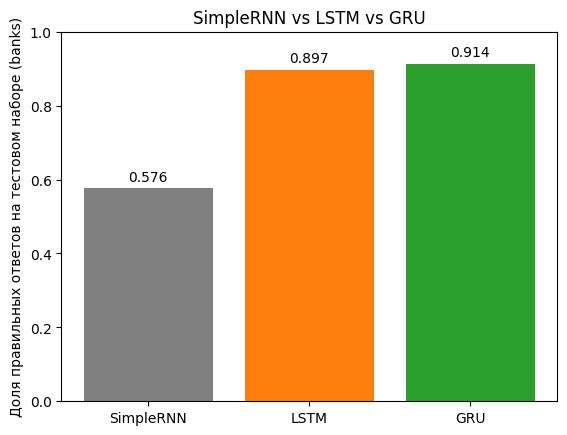

In [4]:
import matplotlib.pyplot as plt

acc = {'SimpleRNN': 0.5764, 'LSTM': 0.8975, 'GRU': 0.9136}
plt.bar(acc.keys(), acc.values(), color=['gray', 'tab:orange', 'tab:green'])
plt.ylim(0, 1)
plt.ylabel('Доля правильных ответов на тестовом наборе (banks)')
plt.title('SimpleRNN vs LSTM vs GRU')
for i, (k, v) in enumerate(acc.items()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 7. Выводы

- Полносвязная сеть не видит порядок слов и привязана к длине входа — поэтому в сетях появился
  **рекуррентный блок**, который обрабатывает последовательность по шагам и хранит состояние.
- SimpleRNN дешев, но затухающие градиенты не дают ему запоминать дальние связи — поэтому появился
  **LSTM** с ячейкой памяти $c_t$ и гейтами.
- LSTM тяжелый, поэтому появился **GRU** — два гейта и одно состояние вместо трёх гейтов и двух
  величин, при почти той же точности.

Новые архитектуры появляются не «просто потому, что», а как ответ на конкретную проблему предыдущей.
Чтобы потренироваться на данных, откройте практические ноутбуки:

- [text_classification_rnn_pytorch.ipynb](text_classification_rnn_pytorch.ipynb)
- [text_classification_lstm_pytorch.ipynb](text_classification_lstm_pytorch.ipynb)
- [text_classification_gru_pytorch.ipynb](text_classification_gru_pytorch.ipynb)